# Lattice surgery on qLDPC codes

Lattice surgery measures logical Pauli operators by coupling encoded data to ancillary qubits and checks.
A Pauli-product measurement (PPM) returns the eigenvalue of a product of Pauli operators: the single-code examples below measure one logical operator, while the joint examples measure a product such as $\bar{Z}_1\otimes\bar{Z}_2$ across two code blocks.

This advanced notebook demonstrates the experimental `qldpc.experimental.surgery` API.
Everything under `qldpc.experimental` is unstable and may change without deprecation, so pin the `qldpc` version when relying on these features.

The notebook has three parts:

1. Build single- and joint-PPM circuits and check their noiseless measurement outcomes.
2. Reproduce structural quantities from published constructions without running distance searches.
3. Build Sinter tasks and run short logical-error-rate estimates intended for demonstration rather than publication.

The complete notebook is designed to stay under ten minutes on a typical multi-core developer workstation.
Publication-scale Monte Carlo belongs in `experiments/lattice_surgery/collect_ler.py`, which supports resumable runs and writes aggregate CSV data.

| Function | Returns | Purpose |
|---|---|---|
| `build_gadget(code, x, *, basis)` | `GadgetLayout` | Ancilla layout for measuring a selected logical $X$ or $Z$ operator |
| `build_bridge(g_l, g_r)` | `Bridge` | Ancilla bridge joining two gadgets for a joint measurement |
| `build_single_ppm_circuit(...)` | `stim.Circuit` | Circuit for one logical Pauli measurement |
| `build_joint_ppm_circuit(...)` | `(stim.Circuit, joint_code)` | Circuit for a logical Pauli product across two code blocks |
| `boost_gadget(...)` | `GadgetLayout` | Add ancillas until a requested expansion criterion is met |
| `logical_state_init(...)` | `str` | Build a per-data-qubit initialization string for a logical state |
| `cheeger_constant(g)` | `float` | Boundary Cheeger constant |
| `keep_only_observable(...)` | `stim.Circuit` | Select one observable for a logical-error-rate task |

References: Cain et al. [arXiv:2603.28627](https://arxiv.org/abs/2603.28627); Webster, Smith, and Cohen [arXiv:2511.15989](https://arxiv.org/abs/2511.15989); Cross et al. [arXiv:2407.18393](https://arxiv.org/abs/2407.18393); Swaroop et al. [arXiv:2410.03628](https://arxiv.org/abs/2410.03628).


## Setup

Run the next cell once in a fresh notebook environment.
IPython's `%pip` magic installs into the active kernel, so the following imports use the same environment.


In [1]:
%%capture
%pip install qldpc matplotlib

In [2]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import sinter
import stim
import sympy

from qldpc import circuits, codes, decoders
from qldpc.circuits.noise_model import DepolarizingNoiseModel
from qldpc.experimental.surgery import (
    boost_gadget,
    build_bridge,
    build_gadget,
    build_joint_ppm_circuit,
    build_single_ppm_circuit,
    cheeger_constant,
    keep_only_observable,
    logical_state_init,
)
from qldpc.objects import Pauli

In [3]:
def raw_observables(circuit: stim.Circuit, shots: int) -> np.ndarray:
    """Return the raw bits defined by the circuit's OBSERVABLE_INCLUDE instructions.

    A detector sampler reports whether each observable differs from its noiseless reference, so it
    does not expose the reference eigenvalue itself. For these truth-table checks, compile_sampler
    provides the physical measurement records whose designated parities give the raw observable
    bits: 0 represents eigenvalue +1 and 1 represents eigenvalue -1.
    """
    sampler = circuit.compile_sampler()
    raw = sampler.sample(shots=shots).astype(np.uint8)
    n_meas = raw.shape[1]
    obs_lines = [ln for ln in str(circuit).splitlines() if ln.startswith("OBSERVABLE_INCLUDE")]
    cols = []
    for line in obs_lines:
        offsets = [int(t.strip("rec[]")) for t in line.split() if t.startswith("rec[")]
        meas_idx = [n_meas + off for off in offsets]
        cols.append(np.bitwise_xor.reduce(raw[:, meas_idx], axis=1))
    return np.stack(cols, axis=1)

## Single-code Pauli-product measurements

A single-code PPM measures one selected logical Pauli operator.
We first build a small Steane-code example and compare its circuit size with an ordinary memory experiment, then check the measurement outcomes for each logical Pauli eigenstate.


### Minimal Steane-code example

In [4]:
# code [[7, 1, 3]] single-PPM circuit.
#
# QUBIT_COORDS lane layout in the timeline-svg below (see
# _surgery_qubit_coordinates in src/qldpc/experimental/surgery/circuit.py):
#
#   y=0  data qubits             (code ids 0..6)
#   y=1  Q' ancillas             (one per data_check touching support = supp(X̄); Steane: 3)
#   y=2  data H_X ancillas       (measure the m_X original X stabilizers)
#   y=3  S_X' ancillas           (new X-type meas-checks; |support|=3 extended HX rows)
#   y=4  data H_Z ancillas       (measure the m_Z original Z stabilizers)
#   y=5  S_Z' ancillas           (gauge-fix Z-type rows from _step2_gauge_fix)
#
# (For basis=Z the S_X' ↔ S_Z' roles swap: y=3 holds the new Z-type meas-checks
#  and y=5 holds the X-type gauge-fix rows.)
#
# x coordinate inside each lane = the qubit's index within its lane group.
# For basis=X the lane assignment matches qubit ID order (0..6 on y=0,
# 7..9 on y=1, 10..12 on y=2, 13..15 on y=3, 16..18 on y=4, 19 on y=5),
# so the timeline-svg reads top-to-bottom in qubit ID order.
steane = codes.SteaneCode()
x_steane = np.asarray(steane.get_logical_ops(Pauli.X)[0]).astype(np.uint8)
print(x_steane)
g = build_gadget(steane, x_steane, basis=Pauli.X)
circuit = build_single_ppm_circuit(g, rounds=3, noise_model=None, data_init="+")
print(f"single-PPM qubits: {circuit.num_qubits}")
print(f"single-PPM detectors: {circuit.num_detectors}")
print(f"single-PPM observables: {circuit.num_observables}")

[0 0 1 0 1 1 0]
single-PPM qubits: 20
single-PPM detectors: 28
single-PPM observables: 2


In [5]:
circuit = circuits.get_memory_experiment(steane, basis=Pauli.X, num_rounds=3)
print(f"memory qubits: {circuit.num_qubits}")
print(f"memory detectors: {circuit.num_detectors}")
print(f"memory observables: {circuit.num_observables}")

memory qubits: 13
memory detectors: 12
memory observables: 1


Call `circuit.diagram("timeline-svg")` to inspect the complete Stim timeline.
The stored notebook omits that diagram because even this small gadget produces a very wide image that is harder to read than the circuit-size summary above.


### Logical-state truth table on a BB `[[36, 8]]` code

This gadget measures $\bar{X}$ on logical qubit 0.
The circuit's `data_init` argument requires one preparation symbol for every physical data qubit, so `logical_state_init` translates a requested logical state into that per-qubit string:

- `"0"` prepares every data qubit in $\lvert 0\rangle$ before projection into the codespace.
- `"+"` similarly prepares every data qubit in $\lvert +\rangle$.
- `"1"` starts from the all-zero preparation and flips the qubits in the support of the selected logical $\bar{X}$ operator.
- `"-"` starts from the all-plus preparation and flips the qubits in the support of the corresponding logical $\bar{Z}$ operator.

The last two cases are why the helper is useful: repeating `"1"` or `"-"` on every physical qubit need not target the intended logical qubit.

`raw_observables` computes the actual measurement parity recorded by `OBSERVABLE_INCLUDE`.
An observable bit of 0 represents eigenvalue $+1$, and a bit of 1 represents eigenvalue $-1$.

| input label | prepared logical state | $\bar{X}$ eigenvalue | expected fraction with `obs0 = 1` |
|---|---|---|---|
| `"0"` | $\lvert 0\rangle_L$ | random because this is a $\bar{Z}$ eigenstate | about 50% |
| `"1"` | $\lvert 1\rangle_L$ | random because this is a $\bar{Z}$ eigenstate | about 50% |
| `"+"` | $\lvert +\rangle_L$ | $+1$ | 0% |
| `"-"` | $\lvert -\rangle_L$ | $-1$ | 100% |

The circuit records the same logical parity in two ways: `obs0` is the surgery measurement and `obs1` is a direct destructive cross-check.
They should agree on every shot.

The $\lvert 0\rangle_L$ and $\lvert 1\rangle_L$ rows deliberately measure $\bar{X}$ on states in the complementary $\bar{Z}$ basis, so their outcomes are random even in a noiseless circuit.
Such a circuit can support this raw-sampler truth-table check, but its random ideal observable is unsuitable for a logical-error-rate calculation.


In [6]:
# Swap in codes.SteaneCode() to run the same table on a self-dual code.
xs, ys = sympy.symbols("x y")
code = codes.BBCode({xs: 3, ys: 6}, xs**3 + ys + ys**2, ys**3 + xs + xs**2)
CODE_LABEL_1 = f"BB [[{code.num_qudits}, {code.dimension}]]"

x_code = np.asarray(code.get_logical_ops(Pauli.X)[0]).astype(np.uint8)
z_code = np.asarray(code.get_logical_ops(Pauli.Z)[0]).astype(np.uint8)
g_code = build_gadget(code, x_code, basis=Pauli.X)

SHOTS = 4000
# logical_state_init(code, state) returns the right per-qubit data_init for
# any CSS code — see surgery.logical_state_init docstring for the asymmetry
# explanation. Plug straight into data_init=.
table = [
    ("|0⟩_L", "0", "random", 0.5, True),
    ("|1⟩_L", "1", "random", 0.5, True),
    ("|+⟩_L", "+", "+1", 0.0, False),
    ("|−⟩_L", "-", "-1", 1.0, False),
]
print(
    f"{CODE_LABEL_1}: wt(X̄_0) = {int(x_code.sum())}, wt(Z̄_0) = {int(z_code.sum())}\n"
    f"logical_state_init places the |1⟩_L / |−⟩_L flip on those supports, so the X̄\n"
    f"eigenvalue below is independent of their parity.\n"
)
print(
    f"{'state':<6} | {'X̄ eigenvalue':<16} | {'expected obs0':<14} | "
    f"{'measured fraction obs0=1':<24} | obs0==obs1 | ok"
)
print("-" * 96)
for label, state, eig, expected, stochastic in table:
    circuit = build_single_ppm_circuit(
        g_code,
        rounds=3,
        noise_model=None,
        data_init=logical_state_init(code, state, log_idx=0),
    )
    # Use raw_observables because these truth tables need the ideal observable sign.
    obs = raw_observables(circuit, SHOTS)
    rate0 = float(obs[:, 0].mean())
    agree = float((obs[:, 0] == obs[:, 1]).mean())
    if stochastic:
        ok = 0.4 < rate0 < 0.6 and agree == 1.0
        exp_str = "~50%"
    else:
        ok = rate0 == expected and agree == 1.0
        exp_str = f"{expected:>4.0%}"
    flag = "✓" if ok else "✗"
    print(
        f"{label:<6} | {eig:<16} | {exp_str:>14} | "
        f"{rate0:>10.2%} ({int(obs[:, 0].sum()):>4}/{SHOTS})    | "
        f"{agree:>7.1%}   | {flag}"
    )
    assert ok, f"failed for state={state!r}"
print(f"\n✓ single-PPM on {CODE_LABEL_1} measures X̄ correctly for all four input states")

BB [[36, 8]]: wt(X̄_0) = 6, wt(Z̄_0) = 8
logical_state_init places the |1⟩_L / |−⟩_L flip on those supports, so the X̄
eigenvalue below is independent of their parity.

state  | X̄ eigenvalue    | expected obs0  | measured fraction obs0=1 | obs0==obs1 | ok
------------------------------------------------------------------------------------------------


|0⟩_L  | random           |           ~50% |     50.02% (2001/4000)    |  100.0%   | ✓


|1⟩_L  | random           |           ~50% |     50.20% (2008/4000)    |  100.0%   | ✓


|+⟩_L  | +1               |             0% |      0.00% (   0/4000)    |  100.0%   | ✓


|−⟩_L  | -1               |           100% |    100.00% (4000/4000)    |  100.0%   | ✓

✓ single-PPM on BB [[36, 8]] measures X̄ correctly for all four input states


## Joint Pauli-product measurements

A joint PPM uses an ancilla bridge to measure the product of logical operators on two code blocks.
The examples below first check deterministic $\bar{Z}_1\otimes\bar{Z}_2$ eigenstates and then repeat the check when one input is a superposition in the measured basis.


### Minimal two-block example

In [7]:
# Inter-code joint Z̄_1 ⊗ Z̄_2 on two Steane copies.
#
# QUBIT_COORDS lane layout in the timeline-svg below — same 6 lanes as single
# PPM, **concatenated** across c_l (left) and c_r (right), plus a 7th lane
# (y=6) for the bridge. Inside each lane, c_l qubits come first, then c_r:
#
#   y=0  data qubits             (c_l data ids 0..n_l-1, then c_r data; here both 7 each)
#   y=1  Q' ancillas             (one per data_check on support in each code; can include
#                                 bridge-augmented extras from build_bridge cellulation)
#   y=2  data H_X ancillas       (m_X^(l) checks first, then m_X^(r); intercode duplicates them)
#   y=3  S_Z' ancillas           (new Z-type meas-checks; |support^(l)| then |support^(r)|;
#                                 this cell is basis=Z — for basis=X this lane is S_X' instead)
#   y=4  data H_Z ancillas       (m_Z^(l) then m_Z^(r))
#   y=5  S_X' ancillas           (gauge-fix X-type rows; |gauge^(l)| then |gauge^(r)|;
#                                 for basis=X this lane is S_Z' instead)
#   y=6  bridge data + bridge cycle ancillas (the b ancillas that physically
#                                 join support^(l) and support^(r); only joint PPM uses this lane)
#
# Intracode joint (g_l.code is g_r.code) shares the y=0 data lane (no duplication)
# but still gets its own Q' / S_X' / S_Z' ancilla groups per gadget.
c1, c2 = codes.SteaneCode(), codes.SteaneCode()
z1 = np.asarray(c1.get_logical_ops(Pauli.Z)[0]).astype(np.uint8)
z2 = np.asarray(c2.get_logical_ops(Pauli.Z)[0]).astype(np.uint8)
g1 = build_gadget(c1, z1, basis=Pauli.Z)
g2 = build_gadget(c2, z2, basis=Pauli.Z)
bridge = build_bridge(g1, g2)
rounds = 3  # any rounds >= 1 reads the same Z̄_1 ⊗ Z̄_2 parity

circuit_default, joint_code = build_joint_ppm_circuit(
    g1,
    g2,
    bridge,
    rounds=rounds,
    noise_model=None,
)
print(f"joint-PPM qubits: {circuit_default.num_qubits}")
print(f"joint-PPM detectors: {circuit_default.num_detectors}")
print(f"joint-PPM observables: {circuit_default.num_observables}")

joint-PPM qubits: 41
joint-PPM detectors: 56
joint-PPM observables: 2


### Deterministic parity truth table

The next circuit measures $\bar{Z}_1\otimes\bar{Z}_2$ between a Steane `[[7, 1, 3]]` code and a BB `[[72, 12]]` code.
Using two different codes exercises the inter-code construction rather than relying on matching block layouts.
For these logical computational-basis inputs, the joint eigenvalue is the product of the two individual $\bar{Z}$ eigenvalues.
As above, `obs0 = 0` represents joint eigenvalue $+1$ and `obs0 = 1` represents $-1$.

| logical input | $\bar{Z}_1$ | $\bar{Z}_2$ | expected `obs0` |
|---|---|---|---|
| $\lvert 0\rangle_L\lvert 0\rangle_L$ | +1 | +1 | 0 |
| $\lvert 0\rangle_L\lvert 1\rangle_L$ | +1 | -1 | 1 |
| $\lvert 1\rangle_L\lvert 0\rangle_L$ | -1 | +1 | 1 |
| $\lvert 1\rangle_L\lvert 1\rangle_L$ | -1 | -1 | 0 |

In [8]:
# Inter-code joint Z̄_1 ⊗ Z̄_2, code-agnostic via logical_state_init.
xs, ys = sympy.symbols("x y")
c1 = codes.SteaneCode()
c2 = codes.BBCode({xs: 6, ys: 6}, xs**3 + ys + ys**2, ys**3 + xs + xs**2)
z1 = np.asarray(c1.get_logical_ops(Pauli.Z)[0]).astype(np.uint8)
z2 = np.asarray(c2.get_logical_ops(Pauli.Z)[0]).astype(np.uint8)
g1 = build_gadget(c1, z1, basis=Pauli.Z)
g2 = build_gadget(c2, z2, basis=Pauli.Z)
bridge = build_bridge(g1, g2)
rounds = 3  # any rounds >= 1 reads the same Z̄_1 ⊗ Z̄_2 parity

circuit_default, joint_code = build_joint_ppm_circuit(
    g1,
    g2,
    bridge,
    rounds=rounds,
    noise_model=None,
)
wt1, wt2 = int(z1.sum()), int(z2.sum())
print(f"joint code           : [[{joint_code.num_qudits}, {joint_code.dimension}]]")
print(f"bridge.width         : {bridge.width}")
print(
    f"extra_ancilla_l, _r  : {bridge.extra_ancilla_l.shape[0]}, {bridge.extra_ancilla_r.shape[0]}"
)
print(
    f"wt(Z̄_1) = {wt1} ({'odd' if wt1 % 2 else 'even'}),  "
    f"wt(Z̄_2) = {wt2} ({'odd' if wt2 % 2 else 'even'})  "
    f"— logical_state_init handles either parity"
)
print()

SHOTS_JOINT = 1000
print(f"{'state':>16} | Z̄_1  Z̄_2 | expected obs0 | fraction with obs0=1 | ok")
print("-" * 86)
joint_pass = True
for s1, s2, sign1, sign2, expected in [
    ("0", "0", "+1", "+1", 0),
    ("0", "1", "+1", "-1", 1),
    ("1", "0", "-1", "+1", 1),
    ("1", "1", "-1", "-1", 0),
]:
    label = f"|{s1}⟩_L|{s2}⟩_L"
    circuit, _ = build_joint_ppm_circuit(
        g1,
        g2,
        bridge,
        rounds=rounds,
        noise_model=None,
        data_init=(
            logical_state_init(c1, s1, log_idx=0),
            logical_state_init(c2, s2, log_idx=0),
        ),
    )
    obs = raw_observables(circuit, SHOTS_JOINT)
    rate = float(obs[:, 0].mean())
    ok = rate == float(expected)
    flag = "✓" if ok else "✗"
    print(
        f"{label:>16} | {sign1:>4}  {sign2:>4} | "
        f"{expected:>13} | {rate:>10.2%} ({int(obs[:, 0].sum()):>3}/{SHOTS_JOINT})    | {flag}"
    )
    joint_pass = joint_pass and ok

assert joint_pass, "joint-PPM correctness failed"
print("\n✓ joint Z̄_1 ⊗ Z̄_2 observable matches expected parity deterministically")

joint code           : [[106, 12]]
bridge.width         : 3
extra_ancilla_l, _r  : 0, 1
wt(Z̄_1) = 3 (odd),  wt(Z̄_2) = 14 (even)  — logical_state_init handles either parity

           state | Z̄_1  Z̄_2 | expected obs0 | fraction with obs0=1 | ok
--------------------------------------------------------------------------------------


      |0⟩_L|0⟩_L |   +1    +1 |             0 |      0.00% (  0/1000)    | ✓


      |0⟩_L|1⟩_L |   +1    -1 |             1 |    100.00% (1000/1000)    | ✓


      |1⟩_L|0⟩_L |   -1    +1 |             1 |    100.00% (1000/1000)    | ✓


      |1⟩_L|1⟩_L |   -1    -1 |             0 |      0.00% (  0/1000)    | ✓

✓ joint Z̄_1 ⊗ Z̄_2 observable matches expected parity deterministically


### Superposition input

Tuple-valued `data_init` allows the two code blocks to use different initial states.
Here `c1` is prepared in $\lvert 0\rangle_L$, a $\bar{Z}$ eigenstate, while `c2` is prepared in $\lvert +\rangle_L$, for which a $\bar{Z}$ measurement is random.
The joint $\bar{Z}_1\otimes\bar{Z}_2$ outcome is therefore also random.

The circuit records this outcome once through the bridged-product measurement and once through a direct destructive cross-check.
Agreement between `obs0` and `obs1` verifies that both routes represent the same logical parity even when its value is not predetermined.
Because the ideal observable is random, this remains a raw-sampler check rather than a logical-error-rate task.


In [9]:
# Prepare c1 in logical |0⟩_L and c2 in logical |+⟩_L.
# Each tuple entry supplies the per-qubit initialization for one code block.
circuit_super, _ = build_joint_ppm_circuit(
    g1,
    g2,
    bridge,
    rounds=rounds,
    noise_model=None,
    data_init=(
        logical_state_init(c1, "0", log_idx=0),
        logical_state_init(c2, "+", log_idx=0),
    ),
)
obs_super = raw_observables(circuit_super, SHOTS_JOINT)
rate0_super = float(obs_super[:, 0].mean())
rate1_super = float(obs_super[:, 1].mean())
agree_super = float((obs_super[:, 0] == obs_super[:, 1]).mean())
print("c1 in |0⟩_L, c2 in |+⟩_L:")
print(f"  obs0 (joint PPM)         : {rate0_super:>6.1%} flips  (expected ~50% — Z̄_2 random)")
print(f"  obs1 (cross-check)  : {rate1_super:>6.1%} flips  (expected ~50%)")
print(f"  obs0 == obs1        : {agree_super:>6.1%}        (expected 100%)")
assert 0.4 < rate0_super < 0.6 and 0.4 < rate1_super < 0.6 and agree_super == 1.0
print("\n✓ joint observable is random (Z̄_2 ⟂ |+⟩) but obs0/obs1 agree on every shot")

c1 in |0⟩_L, c2 in |+⟩_L:
  obs0 (joint PPM)         :  49.3% flips  (expected ~50% — Z̄_2 random)
  obs1 (cross-check)  :  49.3% flips  (expected ~50%)
  obs0 == obs1        : 100.0%        (expected 100%)

✓ joint observable is random (Z̄_2 ⟂ |+⟩) but obs0/obs1 agree on every shot


## Reproduce published gadget properties

The next examples compare the generated gadgets with structural quantities reported in the literature.
Following Webster, $Q'$ denotes the added gadget qubits, while $S'_X$ and $S'_Z$ denote the added $X$- and $Z$-type checks.

### Bare-gadget qubit counts from Webster et al.

The "Gadget Qubits" column in Table 1 of [Webster, Smith, and Cohen](https://arxiv.org/abs/2511.15989) counts the added qubits and check ancillas.
For the $L=1$ gadgets used here, that count is $|Q'|+|S'_X|+|S'_Z|$.
The following cell reconstructs the gadget for the first logical $\bar{X}$ operator of each of the four generalized-bicycle codes in the table.

For the final two codes, Table 1 writes the counts as $49+8$ and $79+20$.
The second term is the later Cheeger-boost contribution, so this first comparison uses the bare-gadget counts 49 and 79.


In [10]:
# Webster, Smith & Cohen, Appendix A (seeds) and Table 1 (gadget qubits):
# https://arxiv.org/abs/2511.15989
# Table 1's "Gadget Qubits" column is written as a sum for the last two codes, (49+8) and
# (79+20), whose second term is the Cheeger-boost addition; the value compared here is the
# bare-gadget first term.
# (ell, k, A exponents, B exponents, X_bar_1 left support, right support, bare gadget qubits)
WEBSTER_TABLE_1_CASES = [
    (31, 10, [0, 6, 15], [0, 5, 7], [1, 6, 8, 10], [11, 26], 19),
    (63, 12, [0, 4, 37], [0, 29, 49], [7, 12, 36, 41, 56], [1, 27, 31, 38, 61], 31),
    (
        127,
        14,
        [0, 32, 100],
        [0, 28, 49],
        [28, 47, 55, 75, 103, 114, 124],
        [4, 14, 15, 23, 50, 77, 83, 109, 123],
        49,
    ),
    (
        255,
        16,
        [0, 39, 55],
        [0, 70, 127],
        [18, 31, 35, 36, 91, 126, 146, 163, 164, 180, 196, 216, 233, 253],
        [48, 52, 87, 101, 103, 106, 107, 125, 140, 156, 179, 211],
        79,
    ),
]

print(f"{'Webster code':<22} {'X̄':<6} | |Q\u2032|  |S_X\u2032|  |S_Z\u2032|   sum  | Table 1")
print("-" * 80)
for code_index, (ell, k, a_exp, b_exp, x_left, x_right, published) in enumerate(
    WEBSTER_TABLE_1_CASES
):
    # Generalised bicycle code: H_X = [A | B], H_Z = [B.T | A.T] over GF(2).
    shift = np.roll(np.eye(ell, dtype=np.int_), shift=-1, axis=0)
    A = sum(np.linalg.matrix_power(shift, exponent) for exponent in a_exp) % 2
    B = sum(np.linalg.matrix_power(shift, exponent) for exponent in b_exp) % 2
    code = codes.CSSCode(np.hstack([A, B]), np.hstack([B.T, A.T]), is_subsystem_code=False)
    x = np.zeros(2 * ell, dtype=np.uint8)
    x[x_left] = 1
    x[ell + np.asarray(x_right)] = 1
    g = build_gadget(code, x, basis=Pauli.X)
    # basis=X: |Q'| = incidence rows (one κ per row); |S_X'| = support; |S_Z'| = gauge rows.
    n_anc, n_X, n_Z = g.incidence.shape[0], len(g.support), g.gauge.shape[0]
    total = n_anc + n_X + n_Z
    label, op = f"[[{2 * ell}, {k}]]", "X̄_1"
    flag = "✓" if total == published else "✗"
    print(
        f"{label:<22} {op:<6} | {n_anc:>4}  {n_X:>6}  {n_Z:>6}   {total:>5}  | "
        f"{published:>5}  {flag}"
    )
    assert total == published, f"Webster code {code_index} ancilla mismatch"
print("\n✓ bare-gadget qubit count matches Table 1 for all 4 codes")

Webster code           X̄     | |Q′|  |S_X′|  |S_Z′|   sum  | Table 1
--------------------------------------------------------------------------------
[[62, 10]]             X̄_1   |    9       6       4      19  |    19  ✓
[[126, 12]]            X̄_1   |   15      10       6      31  |    31  ✓
[[254, 14]]            X̄_1   |   24      16       9      49  |    49  ✓


[[510, 16]]            X̄_1   |   39      26      14      79  |    79  ✓

✓ bare-gadget qubit count matches Table 1 for all 4 codes


### The `bb_18` resource gadget from Cain et al.

The `bb_18` **Resource** row in Extended Data Table 3 of [Cain et al.](https://arxiv.org/abs/2603.28627) reports 39 gadget qubits, 20 $X$ checks, 20 $Z$ checks, and merged-code degree 7.
The **Processor** row in the same table describes a different, larger gadget with counts $(189,104,86)$ and degree 9.

Only two of the three Resource counts are independent.
Choosing a weight-20 logical $\bar{Z}$ representative fixes $|S'_X|=20$, and Webster's construction then gives $|S'_Z|=|Q'|-\operatorname{wt}(\bar{Z})+1=20$ when $|Q'|=39$.
The nontrivial comparisons are therefore the value $|Q'|=39$ and merged-code degree 7.

The cell below reproduces those values in four steps:

1. Construct `bb_18` from the polynomials in Appendix A.2, Eq. (A11), of Cain et al.
2. Load a weight-20 logical $\bar{Z}$ representative and boost seed found by an offline search.
3. Build the bare gadget with `build_gadget`.
4. Add ancilla qubits with `boost_gadget` until the boundary Cheeger constant reaches $h(F)\geq1$.


In [11]:
print("Step 1: Cain App. A 2 Eq. (A11): bb_18 with l=31, m=4")
print("  a = 1 + x^6 y + x^27")
print("  b = y^2 + x^15 y^3 + x^24")
xs, ys = sympy.symbols("x y")
bb18 = codes.BBCode((31, 4), 1 + xs**6 * ys + xs**27, ys**2 + xs**15 * ys**3 + xs**24)
print(f"  built: [[{bb18.num_qubits}, {bb18.dimension}]]  (expected [[248, 10]])")
assert (bb18.num_qubits, bb18.dimension) == (248, 10)

# Cached weight-20 Z̄ representative + fixed boost seed. The pair (rep, seed)
# is the smallest deterministic bundle that reproduces BOTH of Cain's bb_18
# Resource numbers — (|Q'|, |S_X'|, |S_Z'|) = (39, 20, 20) AND merged-code
# degree = 7 (max stab weight in HX_merged ∪ HZ_merged). Most wt-20 reps boost
# to the right triple but a degree of 8–10 because Webster's gauge-fix S_Z' rows
# (the canonical gauge basis is not weight-minimized) sit on many
# Q' ancilla qubits at once. This particular pair keeps all S_Z' rows ≤ wt 7.
print("\nStep 2: load cached wt-20 Z̄ rep")
Z_BAR_SUPPORT = [
    8,
    9,
    14,
    18,
    24,
    34,
    40,
    56,
    75,
    76,
    97,
    111,
    122,
    171,
    202,
    208,
    213,
    218,
    228,
    238,
]
BOOST_SEED = 2
vec_20 = np.zeros(bb18.num_qudits, dtype=np.uint8)
vec_20[Z_BAR_SUPPORT] = 1
# Sanity: vec_20 is a Z-logical (H_X @ vec_20 == 0).
assert not ((np.asarray(bb18.matrix_x).astype(int) @ vec_20) % 2).any(), (
    "vec_20 is not in ker(H_X) — not a Z-logical"
)
print(f"  wt(Z̄) = {int(vec_20.sum())}")

print("\nStep 3: build_gadget")
# swap (matrix_z ↔ matrix_x) so vec_20 (a Z̄ on bb18) becomes the X̄ on target_code
target_code = codes.CSSCode(bb18.matrix_z, bb18.matrix_x, is_subsystem_code=False)
g_bb = build_gadget(target_code, vec_20, basis=Pauli.X)
# basis=X: |Q'| = incidence rows (one κ per row); |S_X'| = support (new X-type checks);
#          |S_Z'| = gauge rows (new Z-type gauge-fix checks).
print(
    f"  bare gadget: (|Q'|={g_bb.incidence.shape[0]}, |S_X'|={len(g_bb.support)}, |S_Z'|={g_bb.gauge.shape[0]})"
)

print(f"\nStep 4: boost_gadget (combinatorial, target h=1.0, seed={BOOST_SEED})")
g_bb_boosted = boost_gadget(
    g_bb, method="combinatorial", target=1.0, max_extra_qubits=20, seed=BOOST_SEED
)
n_Q_b = g_bb_boosted.incidence.shape[0]
n_X_b = len(g_bb_boosted.support)
n_Z_b = g_bb_boosted.gauge.shape[0]
HX_m = np.asarray(g_bb_boosted.HX_merged).astype(int)
HZ_m = np.asarray(g_bb_boosted.HZ_merged).astype(int)
degree = max(int(HX_m.sum(1).max()), int(HZ_m.sum(1).max()))
print(f"  boost added +{n_Q_b - g_bb.incidence.shape[0]} Q\u2032 qubits")
print(f"  boosted gadget : (|Q\u2032|={n_Q_b}, |S_X\u2032|={n_X_b}, |S_Z\u2032|={n_Z_b})")
print(f"  merged degree  : {degree}  (= max stab weight over HX_merged ∪ HZ_merged)")
print("\n  Cain Extended Data Table 3: (39, 20, 20), degree 7")
assert (n_Q_b, n_X_b, n_Z_b) == (39, 20, 20), (
    f"got ({n_Q_b}, {n_X_b}, {n_Z_b}), expected (39, 20, 20)"
)
assert degree == 7, f"got degree {degree}, expected 7"
print("  ✓ EXACT MATCH on (|Q\u2032|, |S_X\u2032|, |S_Z\u2032|) AND degree")

Step 1: Cain App. A 2 Eq. (A11): bb_18 with l=31, m=4
  a = 1 + x^6 y + x^27
  b = y^2 + x^15 y^3 + x^24
  built: [[248, 10]]  (expected [[248, 10]])

Step 2: load cached wt-20 Z̄ rep
  wt(Z̄) = 20

Step 3: build_gadget
  bare gadget: (|Q'|=30, |S_X'|=20, |S_Z'|=11)

Step 4: boost_gadget (combinatorial, target h=1.0, seed=2)


  boost added +9 Q′ qubits
  boosted gadget : (|Q′|=39, |S_X′|=20, |S_Z′|=20)
  merged degree  : 7  (= max stab weight over HX_merged ∪ HZ_merged)

  Cain Extended Data Table 3: (39, 20, 20), degree 7
  ✓ EXACT MATCH on (|Q′|, |S_X′|, |S_Z′|) AND degree


#### Origin of the cached representative

A stochastic BP+OSD search found the weight-20 representative and boost seed used above.
That expensive, nondeterministic search would not demonstrate any additional API behavior, so the notebook uses its cached result to keep this construction deterministic.

For publication-scale logical-error-rate collection on this gadget, use:

```bash
python experiments/lattice_surgery/collect_ler.py \
    --preset bb18 --max-shots 10000 --max-errors 100 --workers 8 \
    --output bb18_results.csv
```


### Structural distance conditions for BB `[[72, 12, 6]]`

Theorem 6 in Section 3.3 of [Cross et al.](https://arxiv.org/abs/2407.18393) gives conditions under which the construction preserves distance.
For the $L=1$ gadgets used here, its expansion condition reduces to $h(F)\geq1$, together with the theorem's irreducibility assumptions.
The cell below checks the structural conditions available directly from this construction:

1. construct the published BB `[[72, 12, 6]]` code;
2. confirm that the bare gadget has $h(F)\geq1$;
3. confirm that the merged checks commute; and
4. confirm that the merged code fixes exactly one logical degree of freedom.

A randomized search could provide only an upper bound on distance, not prove the theorem, and its runtime would be unpredictable.
The notebook therefore omits that search.


In [12]:
xs, ys = sympy.symbols("x y")
bb72 = codes.BBCode({xs: 6, ys: 6}, xs**3 + ys + ys**2, ys**3 + xs + xs**2)
x_bb72 = np.asarray(bb72.get_logical_ops(Pauli.X)[0]).astype(np.uint8)
g_bb72 = build_gadget(bb72, x_bb72, basis=Pauli.X)
h_72 = cheeger_constant(g_bb72)
merged_bb72 = codes.CSSCode(
    g_bb72.HX_merged,
    g_bb72.HZ_merged,
    is_subsystem_code=False,
)
commutator = (
    np.asarray(merged_bb72.matrix_x).astype(int) @ np.asarray(merged_bb72.matrix_z).astype(int).T
) % 2

print(f"input code    : [[{bb72.num_qudits}, {bb72.dimension}, 6]]")
print(f"Cheeger h(F)  : {h_72:.3f}")
print(f"merged code   : [[{merged_bb72.num_qudits}, {merged_bb72.dimension}]]")
assert h_72 >= 1.0
assert not commutator.any()
assert merged_bb72.dimension == bb72.dimension - 1
print("✓ structural distance-screen inputs hold")

input code    : [[72, 12, 6]]
Cheeger h(F)  : 1.000
merged code   : [[84, 11]]
✓ structural distance-screen inputs hold


### Structural distance conditions for `bb_18` `[[248, 10]]`

The same checks apply to the boosted Resource gadget constructed above.
Cain et al. report only the upper bound $d\leq18$, so another randomized upper-bound search could not establish distance preservation.
The notebook omits that search; the offline runner shown below supports larger Monte Carlo studies.


In [13]:
h_bb18 = cheeger_constant(g_bb_boosted)
merged_bb18 = codes.CSSCode(
    g_bb_boosted.HX_merged,
    g_bb_boosted.HZ_merged,
    is_subsystem_code=False,
)
commutator = (
    np.asarray(merged_bb18.matrix_x).astype(int) @ np.asarray(merged_bb18.matrix_z).astype(int).T
) % 2

print(f"input code    : [[{target_code.num_qudits}, {target_code.dimension}, ≤18]]")
print(f"Cheeger h(F)  : {h_bb18:.3f}")
print(f"merged code   : [[{merged_bb18.num_qudits}, {merged_bb18.dimension}]]")
assert h_bb18 >= 1.0
assert not commutator.any()
assert merged_bb18.dimension == target_code.dimension - 1
print("✓ structural distance-screen inputs hold")

input code    : [[248, 10, ≤18]]
Cheeger h(F)  : 1.000
merged code   : [[287, 9]]
✓ structural distance-screen inputs hold


## Short logical-error-rate example on the `[[72, 12]]` BB code

This section compares a single-code surgery measurement with a $\bar{X}$ memory experiment under the same circuit-level noise model.
It demonstrates Sinter task construction, BP+LSD decoding, uncertainty reporting, and plotting, but it is intentionally not a publication-quality benchmark:

- three physical-error rates: `0.0014`, `0.0019`, `0.0025`;
- at most 10,000 shots, with a 20-error stopping target that batches may overshoot; and
- up to four workers, capped by the host CPU count.

Each point is based on at most a few tens of observed failures, so this run does not resolve whether surgery or memory has the lower logical error rate.
Use the offline runner for a higher-statistics comparison.


In [14]:
xs, ys = sympy.symbols("x y")
bbcode = codes.BBCode({xs: 6, ys: 6}, xs**3 + ys + ys**2, ys**3 + xs + xs**2)
x_bbcode = np.asarray(bbcode.get_logical_ops(Pauli.X)[0]).astype(np.uint8)
g_bbcode = build_gadget(bbcode, x_bbcode, basis=Pauli.X)

h_bbcode = cheeger_constant(g_bbcode)
print(f"code         : [[{bbcode.num_qudits}, {bbcode.dimension}]]")
print(f"Cheeger h(F) : {h_bbcode:.3f}  (Webster threshold = 1.0)")
if h_bbcode < 1.0:
    print("→ boosting (h < 1.0)")
    g_bbcode = boost_gadget(
        g_bbcode, method="combinatorial", target=1.0, max_extra_qubits=20, seed=3
    )
    # gadget notation: F → incidence.
    print(
        f"→ boosted F shape: {g_bbcode.incidence.shape}, h(F_aug) = {cheeger_constant(g_bbcode):.3f}"
    )
else:
    print("→ h ≥ 1.0, no boost needed")

code         : [[72, 12]]
Cheeger h(F) : 1.000  (Webster threshold = 1.0)
→ h ≥ 1.0, no boost needed


In [15]:
LER_ROUNDS = 9
LER_P_VALUES = [0.0014, 0.0019, 0.0025]
LER_MAX_SHOTS = 10_000
LER_MAX_ERRORS = 20
LER_NUM_WORKERS = max(1, min(4, os.cpu_count() or 1))

surgery_tasks, memory_tasks = [], []
for p in LER_P_VALUES:
    noise = DepolarizingNoiseModel(p, include_idling_error=False)
    surgery = build_single_ppm_circuit(g_bbcode, rounds=LER_ROUNDS, noise_model=noise)
    surgery_tasks.append(
        sinter.Task(
            circuit=keep_only_observable(surgery, keep_idx=0),
            json_metadata={"p": float(p), "kind": "surgery"},
        )
    )
    memory = circuits.get_memory_experiment(
        bbcode,
        basis=Pauli.X,
        num_rounds=LER_ROUNDS,
        noise_model=noise,
    )
    memory_tasks.append(
        sinter.Task(
            circuit=keep_only_observable(memory, keep_idx=0),
            json_metadata={"p": float(p), "kind": "memory"},
        )
    )

decoder = decoders.ObservableDecoder(
    decoder=decoders.bp_lsd(
        max_iter=20,
        bp_method="ms",
        lsd_method="lsd_cs",
        lsd_order=5,
    )
)

t0 = time.time()
results = sinter.collect(
    tasks=surgery_tasks + memory_tasks,
    decoders=["custom"],
    custom_decoders={"custom": decoder},
    num_workers=LER_NUM_WORKERS,
    max_shots=LER_MAX_SHOTS,
    max_errors=LER_MAX_ERRORS,
    print_progress=False,
)
print(f"collected {len(results)} task results in {time.time() - t0:.1f}s")

collected 6 task results in 218.3s


In [16]:
surgery_lers, memory_lers = {}, {}
for r in results:
    p = r.json_metadata["p"]
    kind = r.json_metadata["kind"]
    ler = r.errors / max(r.shots, 1)
    (surgery_lers if kind == "surgery" else memory_lers)[p] = (ler, r.errors, r.shots)

print(f"{'p':>10} | {'surgery LER':>22} | {'memory LER':>22}")
print(f"{'-' * 10} | {'-' * 22} | {'-' * 22}")
for p in sorted(LER_P_VALUES):
    s, se, ss = surgery_lers.get(p, (np.nan, 0, 0))
    m, me, ms = memory_lers.get(p, (np.nan, 0, 0))
    print(f"{p:>10.4f} | {s:>10.3e} ({se:>3}/{ss:<6}) | {m:>10.3e} ({me:>3}/{ms:<6})")

         p |            surgery LER |             memory LER
---------- | ---------------------- | ----------------------
    0.0014 |  5.000e-04 (  5/10000 ) |  7.000e-04 (  7/10000 )
    0.0019 |  2.270e-03 ( 22/9692  ) |  1.100e-03 ( 11/10000 )
    0.0025 |  7.094e-03 ( 23/3242  ) |  3.117e-03 ( 20/6417  )


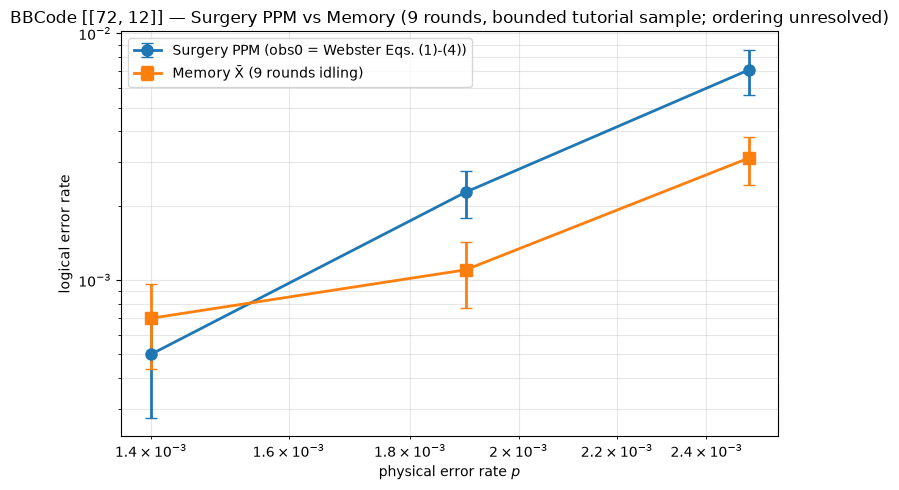

In [17]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ps_sorted = sorted(LER_P_VALUES)


def _ler_with_sigma(table, label):
    """Point estimate and Poisson 1-sigma band. A point with no errors gets the sqrt(1) stand-in.

    A zero-error point has ler = 0, which the log y-axis below cannot draw, so it would vanish from
    the figure without a trace. Those points are named here; decide whether to plot them as an upper
    limit or to move the sweep range so every point has countable errors.
    """
    ler = np.array([table[p][0] for p in ps_sorted])
    counts = np.array([table[p][1] for p in ps_sorted], dtype=float)
    shots = np.array([table[p][2] for p in ps_sorted], dtype=float)
    zero = [p for p, n in zip(ps_sorted, counts) if n == 0]
    if zero:
        print(f"  WARNING {label}: no errors at p in {zero} -- dropped by the log axis")
    return ler, np.sqrt(np.maximum(counts, 1.0)) / shots


surgery_y, surgery_sigma = _ler_with_sigma(surgery_lers, "surgery")
memory_y, memory_sigma = _ler_with_sigma(memory_lers, "memory")
ax.errorbar(
    ps_sorted,
    surgery_y,
    yerr=surgery_sigma,
    fmt="o-",
    label="Surgery PPM (obs0 = Webster Eqs. (1)-(4))",
    markersize=8,
    linewidth=2,
    capsize=4,
)
ax.errorbar(
    ps_sorted,
    memory_y,
    yerr=memory_sigma,
    fmt="s-",
    label=f"Memory X̄ ({LER_ROUNDS} rounds idling)",
    markersize=8,
    linewidth=2,
    capsize=4,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("physical error rate $p$")
ax.set_ylabel("logical error rate")
ax.set_title(
    f"BBCode [[{bbcode.num_qudits}, {bbcode.dimension}]] — Surgery PPM vs Memory "
    f"({LER_ROUNDS} rounds, bounded tutorial sample; ordering unresolved)"
)
ax.legend(loc="upper left")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

### Resource scale for Cain et al.'s `bb_18` gadget

The `bb_18` circuit is useful for comparing resource scale, but it is too expensive for an interactive logical-error-rate sweep.
On a typical workstation, one surgery shot takes roughly 60–100 CPU-seconds, so useful statistics require many hours even with eight workers.

The cell below does not sample either circuit.
It builds the 15-round surgery and 9-round memory tasks used by the offline `bb18` preset, then compares the sizes of their detector error models.
Because the round counts differ, this is a comparison of those specific tasks rather than an equal-duration circuit comparison.
Publication-scale collection is resumable through:

```bash
python experiments/lattice_surgery/collect_ler.py \
    --preset bb18 --max-shots 10000 --max-errors 100 --workers 8 \
    --output bb18_results.csv
```

This Resource gadget is smaller than the Processor gadget used in Extended Data Fig. 1b of Cain et al.
The offline script also uses one BP+LSD decoder instead of the paper's five-decoder ensemble, so it does not reproduce that figure.


In [18]:
RESOURCE_P = 0.007
resource_noise = DepolarizingNoiseModel(RESOURCE_P, include_idling_error=False)
resource_surgery = build_single_ppm_circuit(
    g_bb_boosted,
    rounds=15,
    noise_model=resource_noise,
)
resource_memory = circuits.get_memory_experiment(
    target_code,
    basis=Pauli.X,
    num_rounds=9,
    noise_model=resource_noise,
)
dem_surgery = keep_only_observable(resource_surgery, keep_idx=0).detector_error_model()
dem_memory = keep_only_observable(resource_memory, keep_idx=0).detector_error_model()

print(f"bb_18 [[{target_code.num_qudits}, {target_code.dimension}]] at p={RESOURCE_P}")
print(
    f"  surgery DEM (15 rounds): n_det={dem_surgery.num_detectors}  n_err={dem_surgery.num_errors}"
)
print(f"  memory DEM  (9 rounds): n_det={dem_memory.num_detectors}  n_err={dem_memory.num_errors}")
print(
    f"  ratio      : n_det ×{dem_surgery.num_detectors / dem_memory.num_detectors:.1f}"
    f"  n_err ×{dem_surgery.num_errors / dem_memory.num_errors:.1f}"
)

bb_18 [[248, 10]] at p=0.007
  surgery DEM (15 rounds): n_det=4320  n_err=179983
  memory DEM  (9 rounds): n_det=1240  n_err=13640
  ratio      : n_det ×3.5  n_err ×13.2


### Short joint-PPM logical-error-rate example

This final example measures $\bar{Z}_l\otimes\bar{Z}_r$ across two Steane-code blocks and compares it with a single-code $\bar{Z}$ memory experiment.
The joint measurement uses the bridged-product identity from Section II.B.2 of [Webster, Smith, and Cohen](https://arxiv.org/abs/2511.15989).
Both tasks use nine syndrome-measurement rounds and the same BP+LSD decoder.

As in the preceding example, the sweep is deliberately small: three physical error rates, at most 10,000 shots per task, and a stopping target of 20 observed failures that Sinter's batching may overshoot.


In [19]:
# Swap `make_code()` and `CODE_LABEL` to test other CSS codes.
CODE_LABEL = "Steane [[7,1,3]]"


def make_code():
    return codes.SteaneCode()
    # BB examples (uncomment to swap):
    # xs, ys = sympy.symbols("x y")
    # return codes.BBCode({xs: 6, ys: 6}, xs**3 + ys + ys**2, ys**3 + xs + xs**2)  # [[72, 12]]
    # return codes.BBCode({xs: 3, ys: 6}, xs**3 + ys + ys**2, ys**3 + xs + xs**2)  # [[36, 8]]


LOGICAL_BASIS = Pauli.Z
LOGICAL_IDX = 0  # index into code.get_logical_ops(LOGICAL_BASIS)
BOOST_TARGET = 1.0  # Webster Cheeger threshold h(F) ≥ 1
BOOST_MAX_EXTRA_QUBITS = 20
BOOST_SEED = 3

# === Generic setup (no code-specific code below this line) ===
code_l_j, code_r_j = make_code(), make_code()
logical_op = np.asarray(code_l_j.get_logical_ops(LOGICAL_BASIS)[LOGICAL_IDX]).astype(np.uint8)
g_l_j = build_gadget(code_l_j, logical_op, basis=LOGICAL_BASIS)
g_r_j = build_gadget(code_r_j, logical_op, basis=LOGICAL_BASIS)


def boost_if_needed(label, gadget):
    h_before = cheeger_constant(gadget)
    if h_before >= BOOST_TARGET:
        print(f"  side={label}: h={h_before:.3f} ≥ {BOOST_TARGET} ✓ (no boost)")
        return gadget

    boosted = boost_gadget(
        gadget,
        method="combinatorial",
        target=BOOST_TARGET,
        max_extra_qubits=BOOST_MAX_EXTRA_QUBITS,
        seed=BOOST_SEED,
    )
    h_after = cheeger_constant(boosted)
    print(f"  side={label}: h={h_before:.3f} < {BOOST_TARGET} → boosted to h={h_after:.3f}")
    return boosted


g_l_j = boost_if_needed("l", g_l_j)
g_r_j = boost_if_needed("r", g_r_j)

bridge_j = build_bridge(g_l_j, g_r_j)
print()
print(f"code            : {CODE_LABEL}  (basis={LOGICAL_BASIS.name}, logical[{LOGICAL_IDX}])")
print(f"left/right code : [[{code_l_j.num_qudits}, {code_l_j.dimension}]]")
print(f"bridge          : width={bridge_j.width}, basis={bridge_j.basis.name}")

smoke_circuit_j, joint_code_j = build_joint_ppm_circuit(
    g_l_j,
    g_r_j,
    bridge_j,
    rounds=3,
    noise_model=None,
)
print(f"merged code     : [[{joint_code_j.num_qudits}, {joint_code_j.dimension}]]")
print(
    f"observables     : {smoke_circuit_j.num_observables} (obs0 = Webster joint, obs1 = direct cross-check)"
)

  side=l: h=1.000 ≥ 1.0 ✓ (no boost)
  side=r: h=1.000 ≥ 1.0 ✓ (no boost)

code            : Steane [[7,1,3]]  (basis=Z, logical[0])
left/right code : [[7, 1]]
bridge          : width=3, basis=Z
merged code     : [[21, 1]]
observables     : 2 (obs0 = Webster joint, obs1 = direct cross-check)


In [20]:
LER_ROUNDS_J = 9
LER_P_VALUES_J = [0.002, 0.004, 0.008]
LER_MAX_SHOTS_J = 10_000
LER_MAX_ERRORS_J = 20
LER_NUM_WORKERS_J = max(1, min(4, os.cpu_count() or 1))

surgery_tasks_j, memory_tasks_j = [], []
for p in LER_P_VALUES_J:
    noise = DepolarizingNoiseModel(p, include_idling_error=False)
    surgery = build_joint_ppm_circuit(
        g_l_j,
        g_r_j,
        bridge_j,
        rounds=LER_ROUNDS_J,
        noise_model=noise,
    )[0]
    surgery_tasks_j.append(
        sinter.Task(
            circuit=keep_only_observable(surgery, keep_idx=0),
            json_metadata={"p": float(p), "kind": "joint_surgery"},
        )
    )
    memory = circuits.get_memory_experiment(
        make_code(),
        basis=LOGICAL_BASIS,
        num_rounds=LER_ROUNDS_J,
        noise_model=noise,
    )
    memory_tasks_j.append(
        sinter.Task(
            circuit=keep_only_observable(memory, keep_idx=0),
            json_metadata={"p": float(p), "kind": "single_memory"},
        )
    )

decoder_j = decoders.ObservableDecoder(
    decoder=decoders.bp_lsd(
        max_iter=20,
        bp_method="ms",
        lsd_method="lsd_cs",
        lsd_order=5,
    )
)

t0 = time.time()
results_j = sinter.collect(
    tasks=surgery_tasks_j + memory_tasks_j,
    decoders=["custom"],
    custom_decoders={"custom": decoder_j},
    num_workers=LER_NUM_WORKERS_J,
    max_shots=LER_MAX_SHOTS_J,
    max_errors=LER_MAX_ERRORS_J,
    print_progress=False,
)
print(f"collected {len(results_j)} task results in {time.time() - t0:.1f}s")

collected 6 task results in 2.6s


In [21]:
joint_surg_lers_j, single_mem_lers_j = {}, {}
for r in results_j:
    p = r.json_metadata["p"]
    kind = r.json_metadata["kind"]
    ler = r.errors / max(r.shots, 1)
    (joint_surg_lers_j if kind == "joint_surgery" else single_mem_lers_j)[p] = (
        ler,
        r.errors,
        r.shots,
    )

print(f"{'p':>10} | {'joint Z̄Z̄ surgery':>22} | {'single-code memory':>22}")
print(f"{'-' * 10} | {'-' * 22} | {'-' * 22}")
for p in sorted(LER_P_VALUES_J):
    s, se, ss = joint_surg_lers_j.get(p, (np.nan, 0, 0))
    m, me, ms = single_mem_lers_j.get(p, (np.nan, 0, 0))
    print(f"{p:>10.4f} | {s:>10.3e} ({se:>3}/{ss:<6}) | {m:>10.3e} ({me:>3}/{ms:<6})")

         p |     joint Z̄Z̄ surgery |     single-code memory
---------- | ---------------------- | ----------------------
    0.0020 |  1.696e-02 ( 44/2594  ) |  9.890e-02 ( 27/273   )
    0.0040 |  5.293e-02 ( 28/529   ) |  1.502e-01 ( 41/273   )
    0.0080 |  1.448e-01 ( 21/145   ) |  2.491e-01 ( 68/273   )


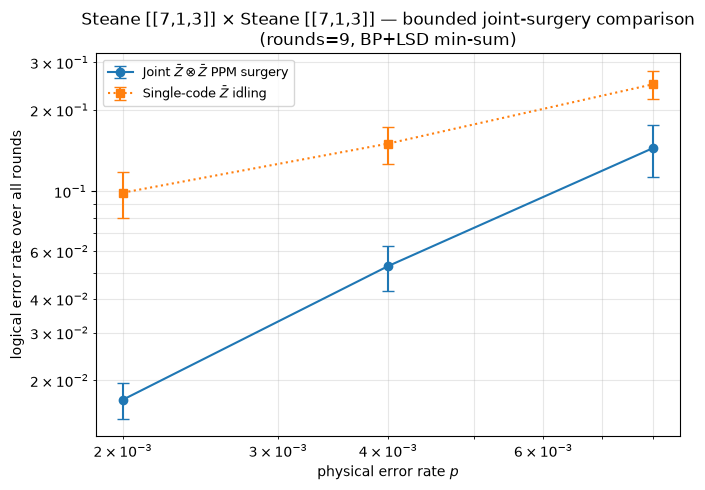

In [22]:
ps_j = sorted(LER_P_VALUES_J)
surg_y_j = np.array([joint_surg_lers_j[p][0] for p in ps_j])
surg_count_j = np.array([joint_surg_lers_j[p][1] for p in ps_j], dtype=float)
surg_shots_j = np.array([joint_surg_lers_j[p][2] for p in ps_j], dtype=float)
mem_y_j = np.array([single_mem_lers_j[p][0] for p in ps_j])
mem_count_j = np.array([single_mem_lers_j[p][1] for p in ps_j], dtype=float)
mem_shots_j = np.array([single_mem_lers_j[p][2] for p in ps_j], dtype=float)

# Poisson standard-error guides for the small observed failure counts.
surg_sigma_j = np.sqrt(np.maximum(surg_count_j, 1.0)) / surg_shots_j
mem_sigma_j = np.sqrt(np.maximum(mem_count_j, 1.0)) / mem_shots_j

fig_j, ax_j = plt.subplots(figsize=(7, 5))
ax_j.errorbar(
    ps_j,
    surg_y_j,
    yerr=surg_sigma_j,
    fmt="o-",
    capsize=4,
    label=r"Joint $\bar{Z}\otimes\bar{Z}$ PPM surgery",
)
ax_j.errorbar(
    ps_j,
    mem_y_j,
    yerr=mem_sigma_j,
    fmt="s:",
    capsize=4,
    label=r"Single-code $\bar{Z}$ idling",
)
ax_j.set_xscale("log")
ax_j.set_yscale("log")
ax_j.set_xlabel("physical error rate $p$")
ax_j.set_ylabel("logical error rate over all rounds")
ax_j.set_title(
    f"{CODE_LABEL} × {CODE_LABEL} — bounded joint-surgery comparison\n"
    f"(rounds={LER_ROUNDS_J}, BP+LSD min-sum)"
)
ax_j.legend(loc="upper left", fontsize=9)
ax_j.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()